**Data ko Load karna aur Check karna**

In [4]:
import pandas as pd

# Data ko read kar rahe hain
df = pd.read_csv('Mall_Customers.csv')

# Sirf dekh rahe hain ki data dikhta kaisa hai
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Preprocessing & Scaling the Data**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the Real Dataset
df = pd.read_csv('Mall_Customers.csv')

# Let's inspect the data
print("--- Dataset Loaded Successfully ---")
print("Total Rows & Columns:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

--- Dataset Loaded Successfully ---
Total Rows & Columns: (200, 5)

First 5 rows of the dataset:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


**Data ko Alag Karna aur Scale Karna**

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. selecting only spending and annual income
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 2. Data scaling for eqity
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaling has been completed.")

Data scaling has been completed.


**Determining Optimal Clusters using the Elbow Method**

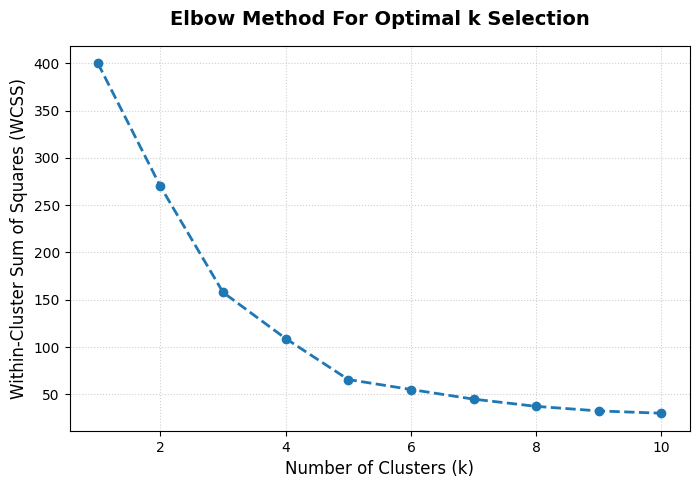

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Initializing Within-Cluster Sum of Squares (WCSS) list
wcss = []

# Iterating from 1 to 10 clusters to evaluate the model performance
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Within-Cluster Sum of Squares (WCSS) vs Number of Clusters
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#1f77b4', linewidth=2)
plt.title('Elbow Method For Optimal k Selection', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Model Fitting and Segment Visualization**

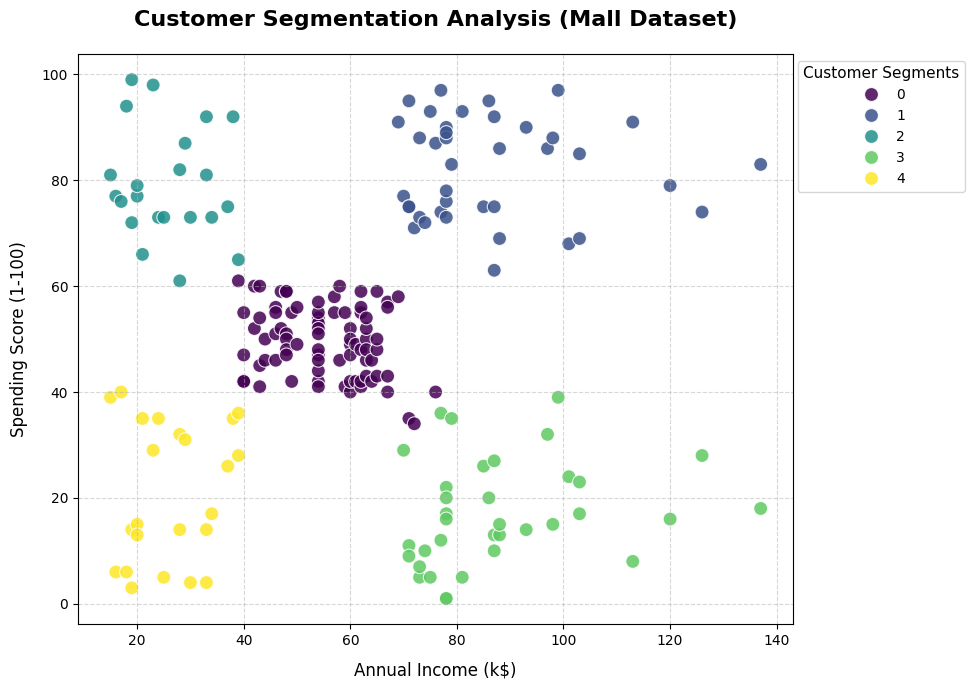

In [8]:
import seaborn as sns

# 1. Initialize and fit the K-Means model with optimal clusters (k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. Configure a professional scatter plot using Seaborn
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis',     # Professional color palette for clear data variance
    s=100,                 # Size of the data points
    alpha=0.85,            # Translucency for overlapping points
    edgecolor='w'
)

# 3. Customizing the plot aesthetics to meet professional standards
plt.title('Customer Segmentation Analysis (Mall Dataset)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Annual Income (k$)', fontsize=12, labelpad=10)
plt.ylabel('Spending Score (1-100)', fontsize=12, labelpad=10)
plt.legend(title='Customer Segments', title_fontsize='11', loc='upper right', bbox_to_anchor=(1.25, 1))
plt.grid(True, linestyle='--', alpha=0.5)

# Display the final analytical plot
plt.tight_layout()
plt.show()

**Tactical Application: Code Upgrade for Enhanced Aesthetics**

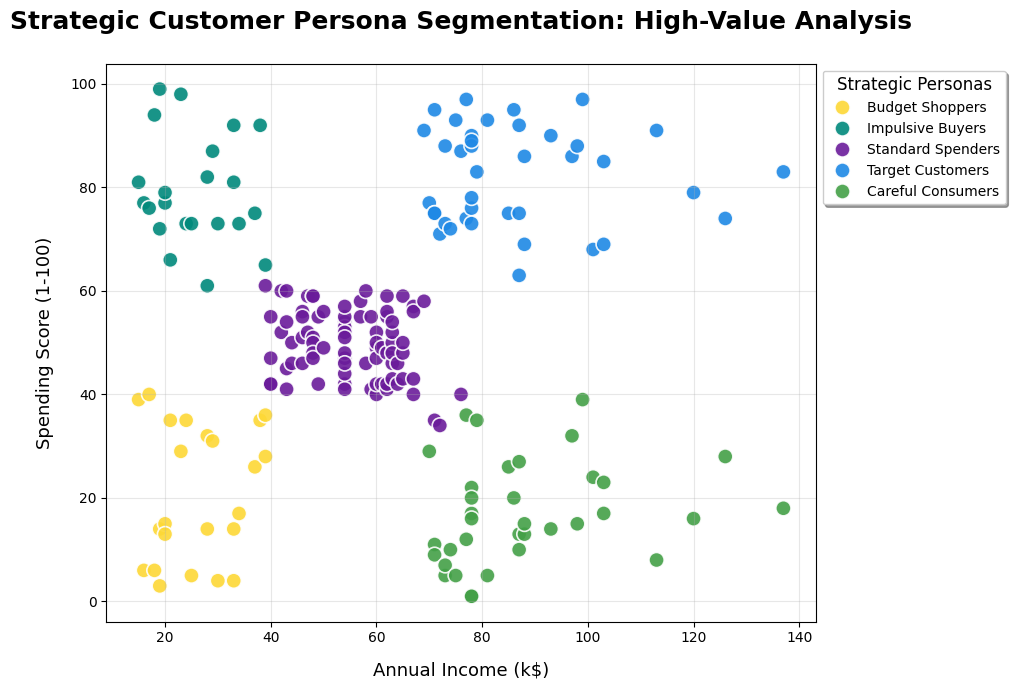

In [9]:
# Create a dictionary to map numerical Cluster IDs to strategic Persona names
persona_map = {
    0: 'Standard Spenders',
    1: 'Target Customers',
    2: 'Impulsive Buyers',
    3: 'Careful Consumers',
    4: 'Budget Shoppers'
}

# Apply the mapping to create a new, readable 'Persona' column
df['Persona'] = df['Cluster'].map(persona_map)

# Define a custom, vibrant professional color palette for enhanced differentiation
custom_palette = {
    'Target Customers': '#1E88E5',   # Distinct blue
    'Careful Consumers': '#43A047',   # Defined green
    'Standard Spenders': '#6A1B9A',  # Strong purple
    'Impulsive Buyers': '#00897B',   # Teal for contrast
    'Budget Shoppers': '#FDD835'     # Yellow for visibility
}

# Configure the advanced strategic plot using Seaborn and the new persona labels
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Persona',                  # Use the named personas instead of Cluster IDs
    data=df,
    palette=custom_palette,        # Apply the custom color strategy
    s=120,                          # Increased point size for presence
    alpha=0.9,                      # Higher visibility
    edgecolor='white',
    linewidth=1.2                   # Distinct point outlines
)

# Refine professional styling and layout
plt.title('Strategic Customer Persona Segmentation: High-Value Analysis', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Annual Income (k$)', fontsize=13, fontweight='medium', labelpad=12)
plt.ylabel('Spending Score (1-100)', fontsize=13, fontweight='medium', labelpad=12)

# Position the refined, descriptive legend carefully on the right
plt.legend(
    title='Strategic Personas',
    title_fontsize='12',
    fontsize='10',
    loc='upper left',
    bbox_to_anchor=(1, 1),
    frameon=True,
    shadow=True
)

# Apply subtle, distinct gridlines for professional clarity
plt.grid(True, linestyle='-', alpha=0.3)

# Display the final strategic report visual
plt.tight_layout()
plt.show()

In [10]:
# 1. Export the updated DataFrame to a structured CSV file
output_filename = 'Strategic_Customer_Segments.csv'
df.to_csv(output_filename, index=False)

print(f"Success! Final dataset exported as '{output_filename}'.")
print("You can download this file from the left-side file explorer pane in Colab.")

Success! Final dataset exported as 'Strategic_Customer_Segments.csv'.
You can download this file from the left-side file explorer pane in Colab.
